##  BÀI TẬP xử lý chuỗi 1.2
**Họ và tên:** Nguyễn Quang Linh
**MSSV:** 038205003016

In [1]:
import pandas as pd

## import dataSet 

In [2]:
file_path = '../data/Elearning01/smsspamcollection/SMSSpamCollection'
df = pd.read_csv(
    file_path, 
    sep='\t', 
    header=None, 
    names=['Label', 'Message']
)

### 1. Đếm xem có bao nhiêu dòng và bao nhiêu dòng xuất hiện spam và bao nhiêu dòng xuất hiện ham trong file trên
### 2. Đếm xem có bao nhiêu từ (các từ ngăn cách bởi khoảng trắng, và không phải chữ số)
### 3. Đếm xem có bao nhiêu từ 'you' (không phân biệt hoa thường)
### 4. Đếm xem có bao nhiêu từ khác nhau (không phân biết hoa thường)
### 5. Liệt kê 10 từ khóa xuất hiện nhiều nhất trong file dữ liệu (không phân biết hoa thường)

In [3]:
df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### 1. Đếm xem có bao nhiêu dòng và bao nhiêu dòng xuất hiện spam và bao nhiêu dòng xuất hiện ham trong file trên

In [4]:
df['Label'].value_counts()

Label
ham     4825
spam     747
Name: count, dtype: int64

### 2. Đếm xem có bao nhiêu từ (các từ ngăn cách bởi khoảng trắng, và không phải chữ số)

In [5]:
df['word_count'] = df['Message'].apply(lambda x: len([w for w in  x.split() if not w.isdigit()]))  
df.head()

,Label,Message,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,26
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


### 3. Đếm xem có bao nhiêu từ 'you' (không phân biệt hoa thường)

In [6]:
you_count = df['Message'].apply(lambda x : x.lower().split().count('you'))
print(f'Count word you: {you_count.sum()}')

Count word you: 1921


### 4. Đếm xem có bao nhiêu từ khác nhau (không phân biết hoa thường)

In [7]:
all_words = df['Message'].str.lower().str.split().explode() 

unique_words = all_words.unique()
print(f'The number of unique words: {len(unique_words)}')

The number of unique words: 13579


### 5. Liệt kê 10 từ khóa xuất hiện nhiều nhất trong file dữ liệu (không phân biết hoa thường)

Message
to     2237
i      2217
you    1921
a      1433
the    1329
u       998
and     968
is      869
in      859
my      755
Name: count, dtype: int64


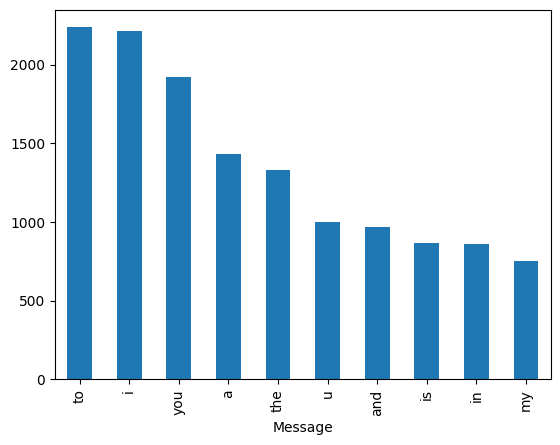

In [11]:
all_words =df['Message'].str.lower().str.split().explode()
top10_words = all_words.value_counts().head(10)
top10_words.plot.bar()
print(top10_words)